# QMC on Manifolds

## Setup

In [2]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP")

    MPLP['PW'] = 30
    MPLP['FS'] = 30
    MPLP['COLORS'] a list of length 10
    MPLP['LINESTYLES'] a list of length 10
    MPLP['MARKERS'] a list of length 12


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda


## Sphere

### Kernels and Transforms

In [4]:
def kernel_sphere_a(x, y):
    assert x.size(-1)==3
    assert y.size(-1)==3
    y = 2-torch.linalg.norm(x-y,dim=-1)
    return y/(2/3)
def kernel_sphere_b(x, y):
    assert x.size(-1)==3 
    assert y.size(-1)==3
    y = 48*torch.exp(-12*torch.linalg.norm(x-y,dim=-1)**2)
    return y/(1-np.exp(-48))
def unif_to_sphere(u):
    assert u.size(-1)==2
    t = torch.sqrt(u[...,1]-u[...,1]**2)
    x = torch.stack([
        2*torch.cos(2*np.pi*u[...,0])*t,
        2*torch.sin(2*np.pi*u[...,0])*t,
        1-2*u[...,1],
        ],dim=-1)
    return x
def sphere_to_unif(x):
    u1 = (1-x[...,2])/2
    t = torch.sqrt(u1-u1**2)
    u0 = (torch.atan2(x[...,1]/(2*t),x[...,0]/(2*t))%(2*np.pi))/(2*np.pi)
    u = torch.stack([
        u0,
        u1,
        ],dim=-1)
    return u
def discrepancy(kernel, x, w, return_kmat=False):
    assert x.ndim>=2
    assert x.size(-2)==w.size(-1)
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (...,n,n)
    discrep = torch.einsum("...i,...ij,...j->...",w,kmat,w)-2*w.sum()+1 # (...,)
    if return_kmat:
        return discrep,kmat 
    else:
        return discrep

### Optimization Routines

In [5]:
def opt_weights(x, kernel):
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat,upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w
    
def opt_points_weights(
        n,
        kernel,
        iters = 100,
        eps_kmat = 0,
        seed = None,
        verbose = None, 
        verbose_indent = 4,
        ):
    unifs = torch.from_numpy(qp.DigitalNetB2(2,seed=seed)(n)).to(DEVICE) # (n,2)
    u0 = np.sqrt(2)*torch.erfinv(2*unifs.flatten()-1) # (n*2,)
    zerosn = torch.zeros(n,device=DEVICE)
    onesn = torch.ones(n,device=DEVICE)
    eyen = torch.eye(n,device=DEVICE)
    def discrepancy_loss(u):
        u = u.reshape((*u.shape[:-1],n,2))
        x = unif_to_sphere(1/2*(1+torch.erf(u/np.sqrt(2))))
        kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (n,n)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        # discrep = 1-(v**2).sum(-1)
        return v
    u = agsutil.lm_opt(
        f = discrepancy_loss,
        theta0 = u0.flatten(),
        ytrue = zerosn,
        iters = iters,
        verbose = verbose,
        verbose_indent = verbose_indent,
        jacfwd = False,
        lam0 = 1e-1,
        lam_factors = [[1/2,1,2]],
        alpha_factors = [[1/2,1,2]],
        minimize = False,
        loss_shift = 1,
    )
    u = u.reshape((*u.shape[:-1],n,2))
    x = unif_to_sphere(1/2*(1+torch.erf(u/np.sqrt(2))))
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (n,n)
    L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
    v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    return x,w

    
opt_points_weights(
    n = 2**7, 
    kernel = kernel_sphere_b,
    seed = 17);

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 3.1e-02   | 3.1e-02   | 3.1e-02   | 3.1e-02   | 3.1e-02   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.6        
    5          | 8.0e-03   | 8.0e-03   | 8.0e-03   | 8.0e-03   | 8.0e-03   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 3.1e-02   | 3.1e-02   | 3.1e-0

### Point and Weight Generators

In [6]:
def get_sphere_iid_x_equal_w(n, seed=None, verbose=True):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    x = unif_to_sphere(torch.rand(n,2,generator=rng,device=DEVICE)) # (n,3)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def get_sphere_iid_x_opt_w_A(n, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    x = unif_to_sphere(torch.rand(n,2,generator=rng,device=DEVICE)) # (n,3)
    w = opt_weights(x,kernel_sphere_a)
    return x,w
def get_sphere_iid_x_opt_w_B(n, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    x = unif_to_sphere(torch.rand(n,2,generator=rng,device=DEVICE)) # (n,3)
    w = opt_weights(x,kernel_sphere_b)
    return x,w
def get_sphere_ldtf_x_equal_w(n, seed=None, verbose=None):
    x = unif_to_sphere(torch.from_numpy(qp.Faure(2,seed=seed,randomize="NUS",warn=False)(n)).to(DEVICE))  # (n,3)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def get_sphere_ldtf_x_opt_w_A(n, seed=None, verbose=None):
    x = unif_to_sphere(torch.from_numpy(qp.Faure(2,seed=seed,randomize="NUS",warn=False)(n)).to(DEVICE))  # (n,3)
    w = opt_weights(x,kernel_sphere_a)
    return x,w
def get_sphere_ldtf_x_opt_w_B(n, seed=None, verbose=None):
    x = unif_to_sphere(torch.from_numpy(qp.Faure(2,seed=seed,randomize="NUS",warn=False)(n)).to(DEVICE))  # (n,3)
    w = opt_weights(x,kernel_sphere_b)
    return x,w
def get_sphere_opt_x_opt_w_A(n, seed=None, verbose=None):
    x,w = opt_points_weights(n,kernel_sphere_a,seed=seed,verbose=verbose)
    return x,w
def get_sphere_opt_x_opt_w_B(n, seed=None, verbose=None):
    x,w = opt_points_weights(n,kernel_sphere_b,seed=seed,verbose=verbose)
    return x,w

### Fixed $n$ & Point-Weight plot

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 1.1e-03   | 1.1e-03   | 1.1e-03   | 1.1e-03   | 1.1e-03   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 1.0e+00   | 0.0        
    5          | 9.7e-04   | 9.7e-04   | 9.7e-04   | 9.7e-04   | 9.7e-04   | 3.1e-03   | 3.1e-03   | 3.1e-03   | 3.1e-03   | 3.1e-03   | 3.2e+01   | 3.2e+01   | 3.2e+0

,Discrep $H^{3/2}(\mathbb{S}^2)$ Kernel,Discrep $H^\infty(\mathbb{S}^2)$ Kernel
IID $x$ ~ Equal $w$,0.009432,0.359573
IID $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,0.002367,0.184072
IID $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,0.020442,0.127625
TF Faure $x$ ~ Equal $w$,0.001387,0.078737
TF Faure $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,0.001217,0.057265
TF Faure $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,0.003564,0.047096
Opt $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,0.000848,0.002332
Opt $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,0.000892,0.002509


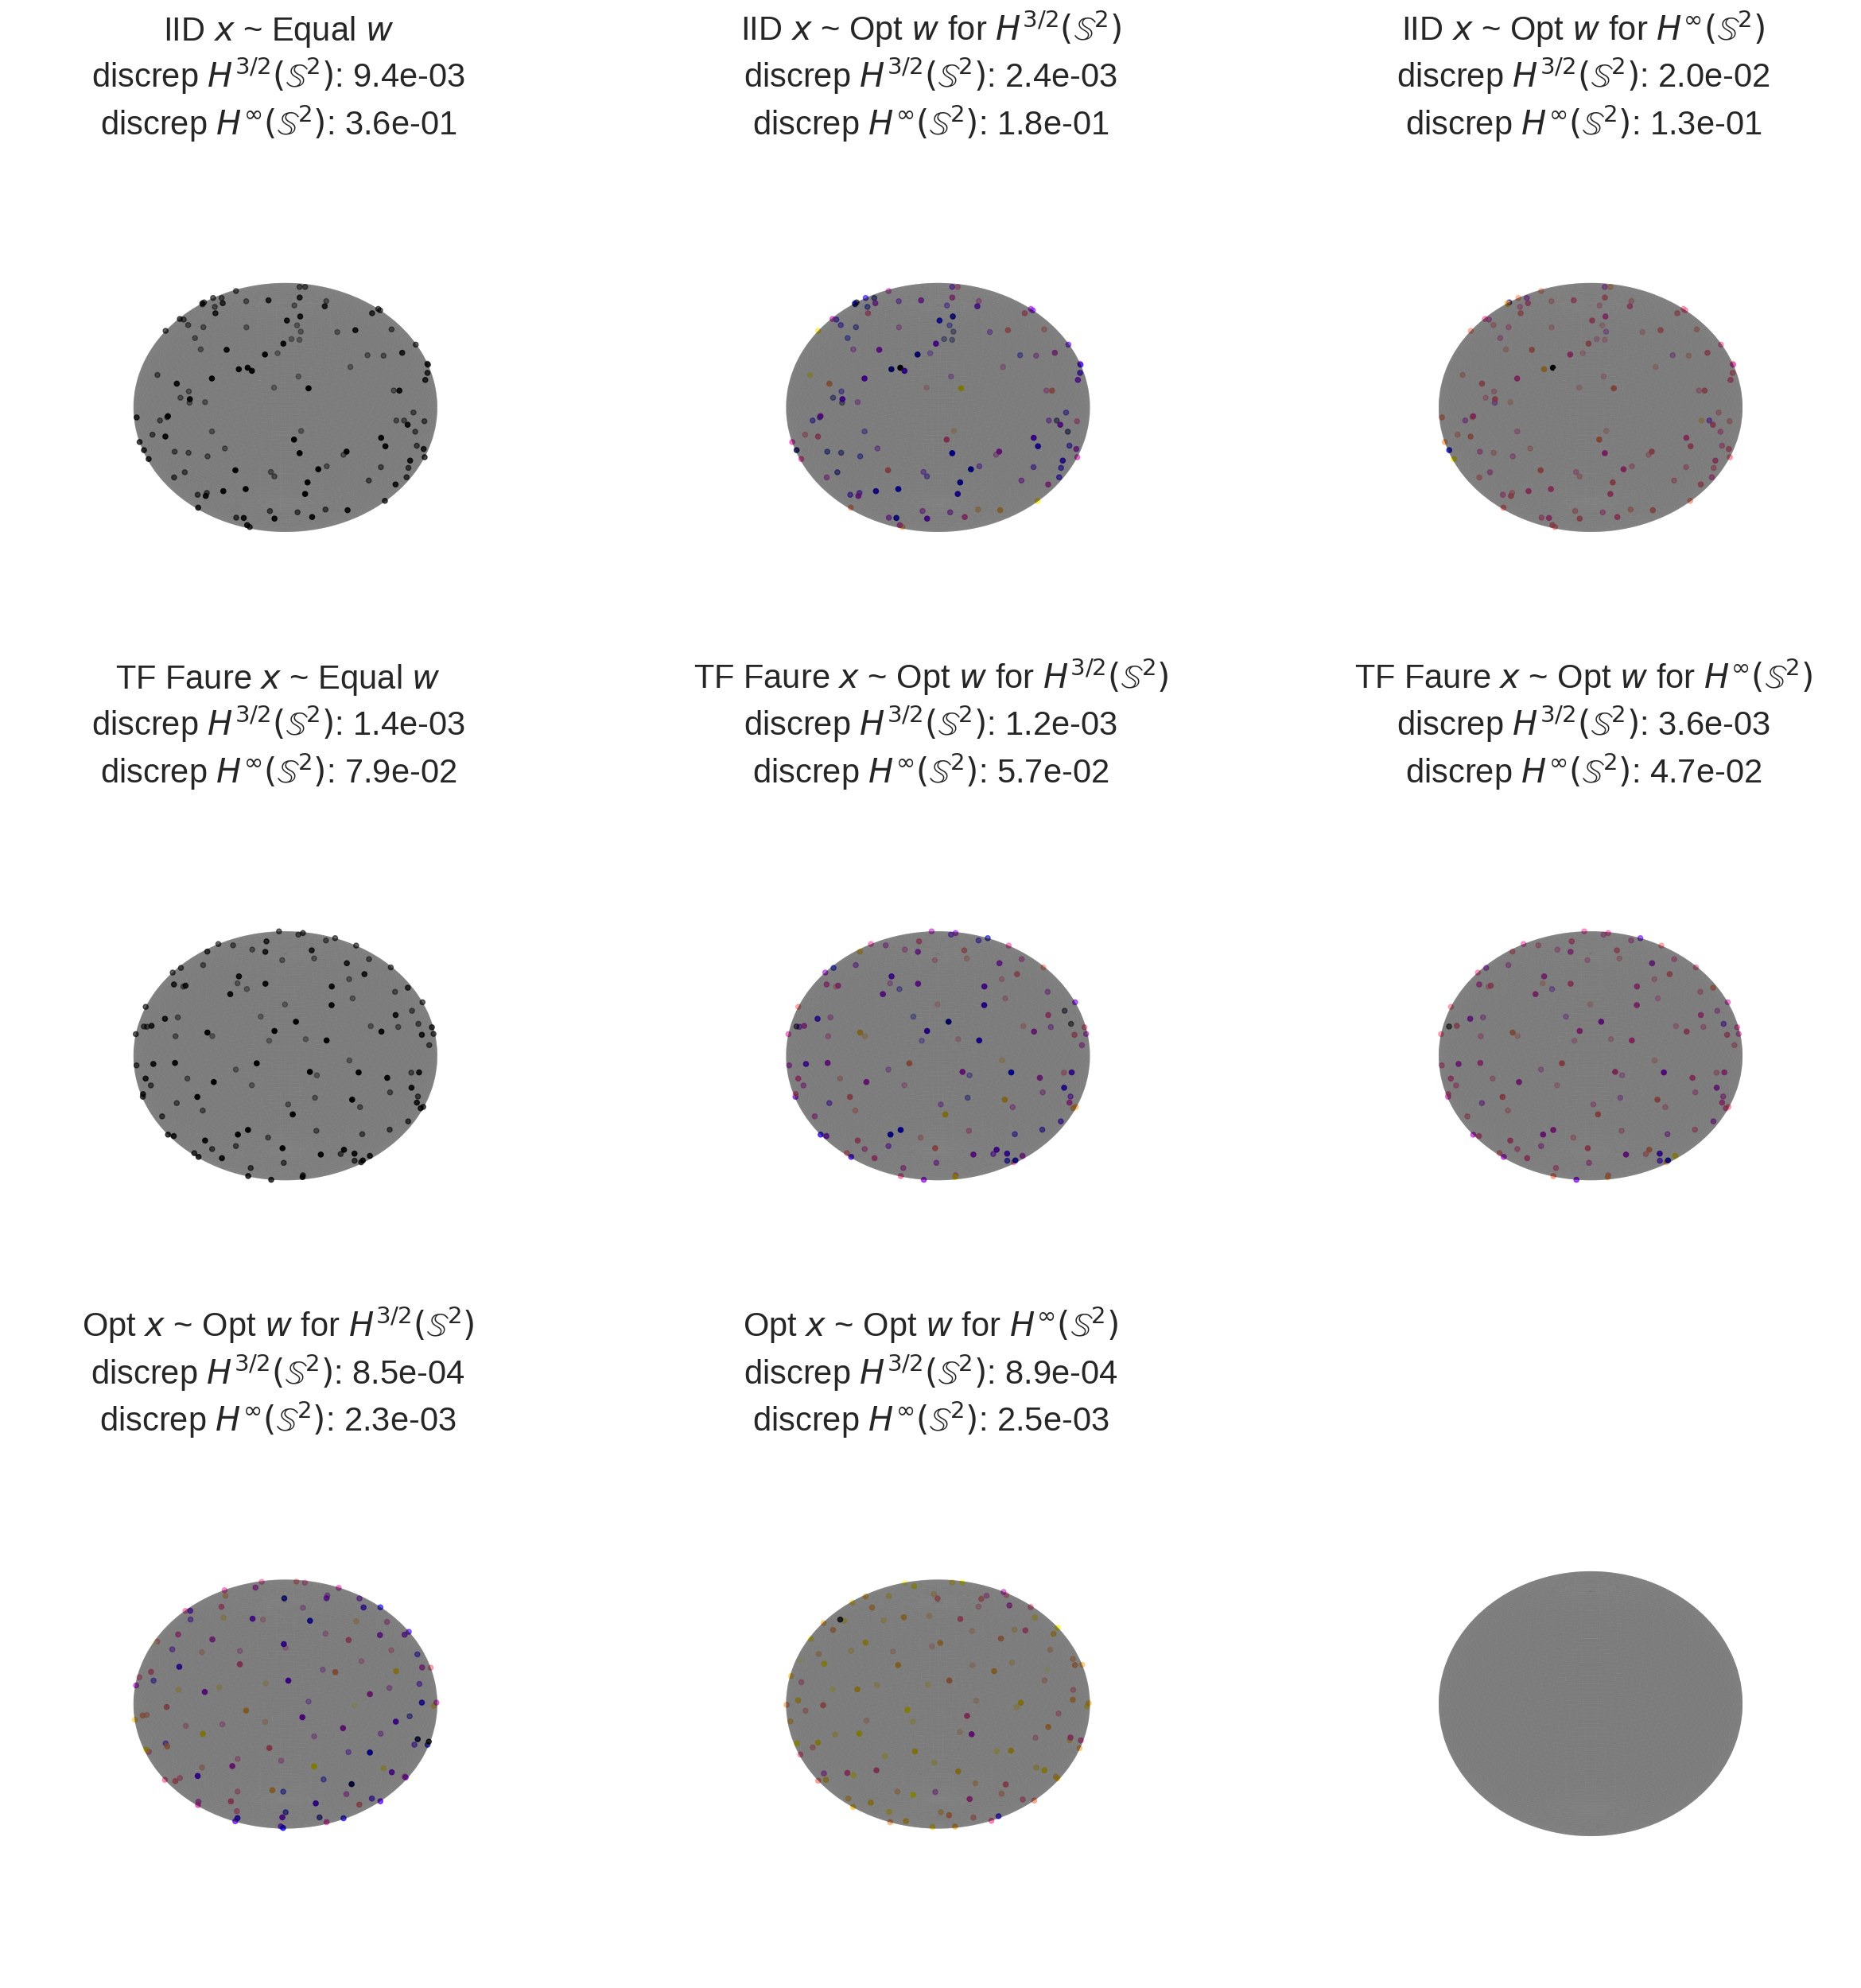

In [7]:
def get_spheres_fig_ax(nrows=1,ncols=1,showaxis=False,figwidth=MPLP["PW"],alpha=.3):
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(figwidth,figwidth/ncols*nrows),subplot_kw={"projection":"3d"})
    ax = np.atleast_1d(ax).reshape((nrows,ncols))
    phimesh,thetamesh = torch.meshgrid(torch.linspace(0,np.pi,100),torch.linspace(0,2*np.pi,100),indexing="ij")
    xmesh = torch.sin(phimesh)*torch.cos(thetamesh)
    ymesh = torch.sin(phimesh)*torch.sin(thetamesh)
    zmesh = torch.cos(phimesh)
    for i in range(nrows):
        for j in range(ncols):
            ax[i,j].plot_surface(xmesh,ymesh,zmesh,rstride=1,cstride=1,color='k',alpha=alpha,linewidth=0)
            if not showaxis:
                ax[i,j].axis("off")
    return fig,ax
seed = 17
n = 2**7
sphere_funcs = [
    [r"IID $x$ ~ Equal $w$", get_sphere_iid_x_equal_w], 
    [r"IID $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$", get_sphere_iid_x_opt_w_A],
    [r"IID $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$", get_sphere_iid_x_opt_w_B],
    [r"TF Faure $x$ ~ Equal $w$", get_sphere_ldtf_x_equal_w],
    [r"TF Faure $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$", get_sphere_ldtf_x_opt_w_A],
    [r"TF Faure $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$", get_sphere_ldtf_x_opt_w_B],
    [r"Opt $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$", get_sphere_opt_x_opt_w_A],
    [r"Opt $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$", get_sphere_opt_x_opt_w_B],
]
discreps = {}
nrows,ncols = 3,3
fig,ax = get_spheres_fig_ax(nrows=nrows,ncols=ncols)
for j,(key,sphere_func) in enumerate(sphere_funcs):
    x,w = sphere_func(n=n,seed=seed)
    j1,j2 = j//ncols,j%ncols
    assert torch.allclose(torch.linalg.norm(x,dim=-1),torch.ones(1,device=DEVICE))
    discrep_a = float(discrepancy(kernel_sphere_a,x,w).cpu())
    discrep_b = float(discrepancy(kernel_sphere_b,x,w).cpu())
    discreps[key] = [discrep_a,discrep_b]
    ax[j1,j2].scatter(x[:,0].cpu(),x[:,1].cpu(),x[:,2].cpu(),cmap="gnuplot2",c=w.cpu())
    ax[j1,j2].set_title(key+"\n"
        +r"discrep $H^{3/2}(\mathbb{S}^2)$: %.1e"%discrep_a+"\n"
        +r"discrep $H^\infty(\mathbb{S}^2)$: %.1e"%discrep_b)
discreps = pd.DataFrame(discreps).T
discreps.columns = [r"Discrep $H^{3/2}(\mathbb{S}^2)$ Kernel",r"Discrep $H^\infty(\mathbb{S}^2)$ Kernel"]
discreps

### Discrepancy Across $n$ Plot

In [8]:
sphere_funcs = [
    [r"IID $x$ ~ Equal $w$", get_sphere_iid_x_equal_w], 
    [r"IID $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$", get_sphere_iid_x_opt_w_A],
    [r"IID $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$", get_sphere_iid_x_opt_w_B],
    [r"TF Faure $x$ ~ Equal $w$", get_sphere_ldtf_x_equal_w],
    [r"TF Faure $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$", get_sphere_ldtf_x_opt_w_A],
    [r"TF Faure $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$", get_sphere_ldtf_x_opt_w_B],
    [r"Opt $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$", get_sphere_opt_x_opt_w_A],
    [r"Opt $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$", get_sphere_opt_x_opt_w_B],
]
n = 2**torch.arange(2,9)
trials = 5
seeds = [i for i in range(trials)]
discreps_a = torch.empty((len(sphere_funcs),len(n),trials))
discreps_b = torch.empty((len(sphere_funcs),len(n),trials))
t0 = time.perf_counter()
for i,(key,sphere_func) in enumerate(sphere_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            x,w = sphere_func(n=n[j],seed=seeds[t],verbose=False)
            discreps_a[i,j,t] = float(discrepancy(kernel_sphere_a,x,w).cpu())
            discreps_b[i,j,t] = float(discrepancy(kernel_sphere_b,x,w).cpu())
            print("        trial %-10d time %-10.1f discrep_a %-10.1e discrep_b %-10.1e"%(t,time.perf_counter()-t0,discreps_a[i,j,t],discreps_b[i,j,t]))

IID $x$ ~ Equal $w$
    n = 4
        trial 0          time 0.0        discrep_a 6.0e-01    discrep_b 1.5e+01   
        trial 1          time 0.0        discrep_a 4.6e-01    discrep_b 1.2e+01   
        trial 2          time 0.0        discrep_a 3.5e-01    discrep_b 1.1e+01   
        trial 3          time 0.0        discrep_a 2.1e-01    discrep_b 1.1e+01   
        trial 4          time 0.0        discrep_a 4.8e-01    discrep_b 1.1e+01   
    n = 8
        trial 0          time 0.0        discrep_a 1.9e-01    discrep_b 6.0e+00   
        trial 1          time 0.0        discrep_a 5.0e-01    discrep_b 6.3e+00   
        trial 2          time 0.0        discrep_a 2.1e-01    discrep_b 5.8e+00   
        trial 3          time 0.0        discrep_a 2.3e-01    discrep_b 5.3e+00   
        trial 4          time 0.0        discrep_a 2.6e-01    discrep_b 6.2e+00   
    n = 16
        trial 0          time 0.0        discrep_a 1.1e-01    discrep_b 2.7e+00   
        trial 1          time 0.0   

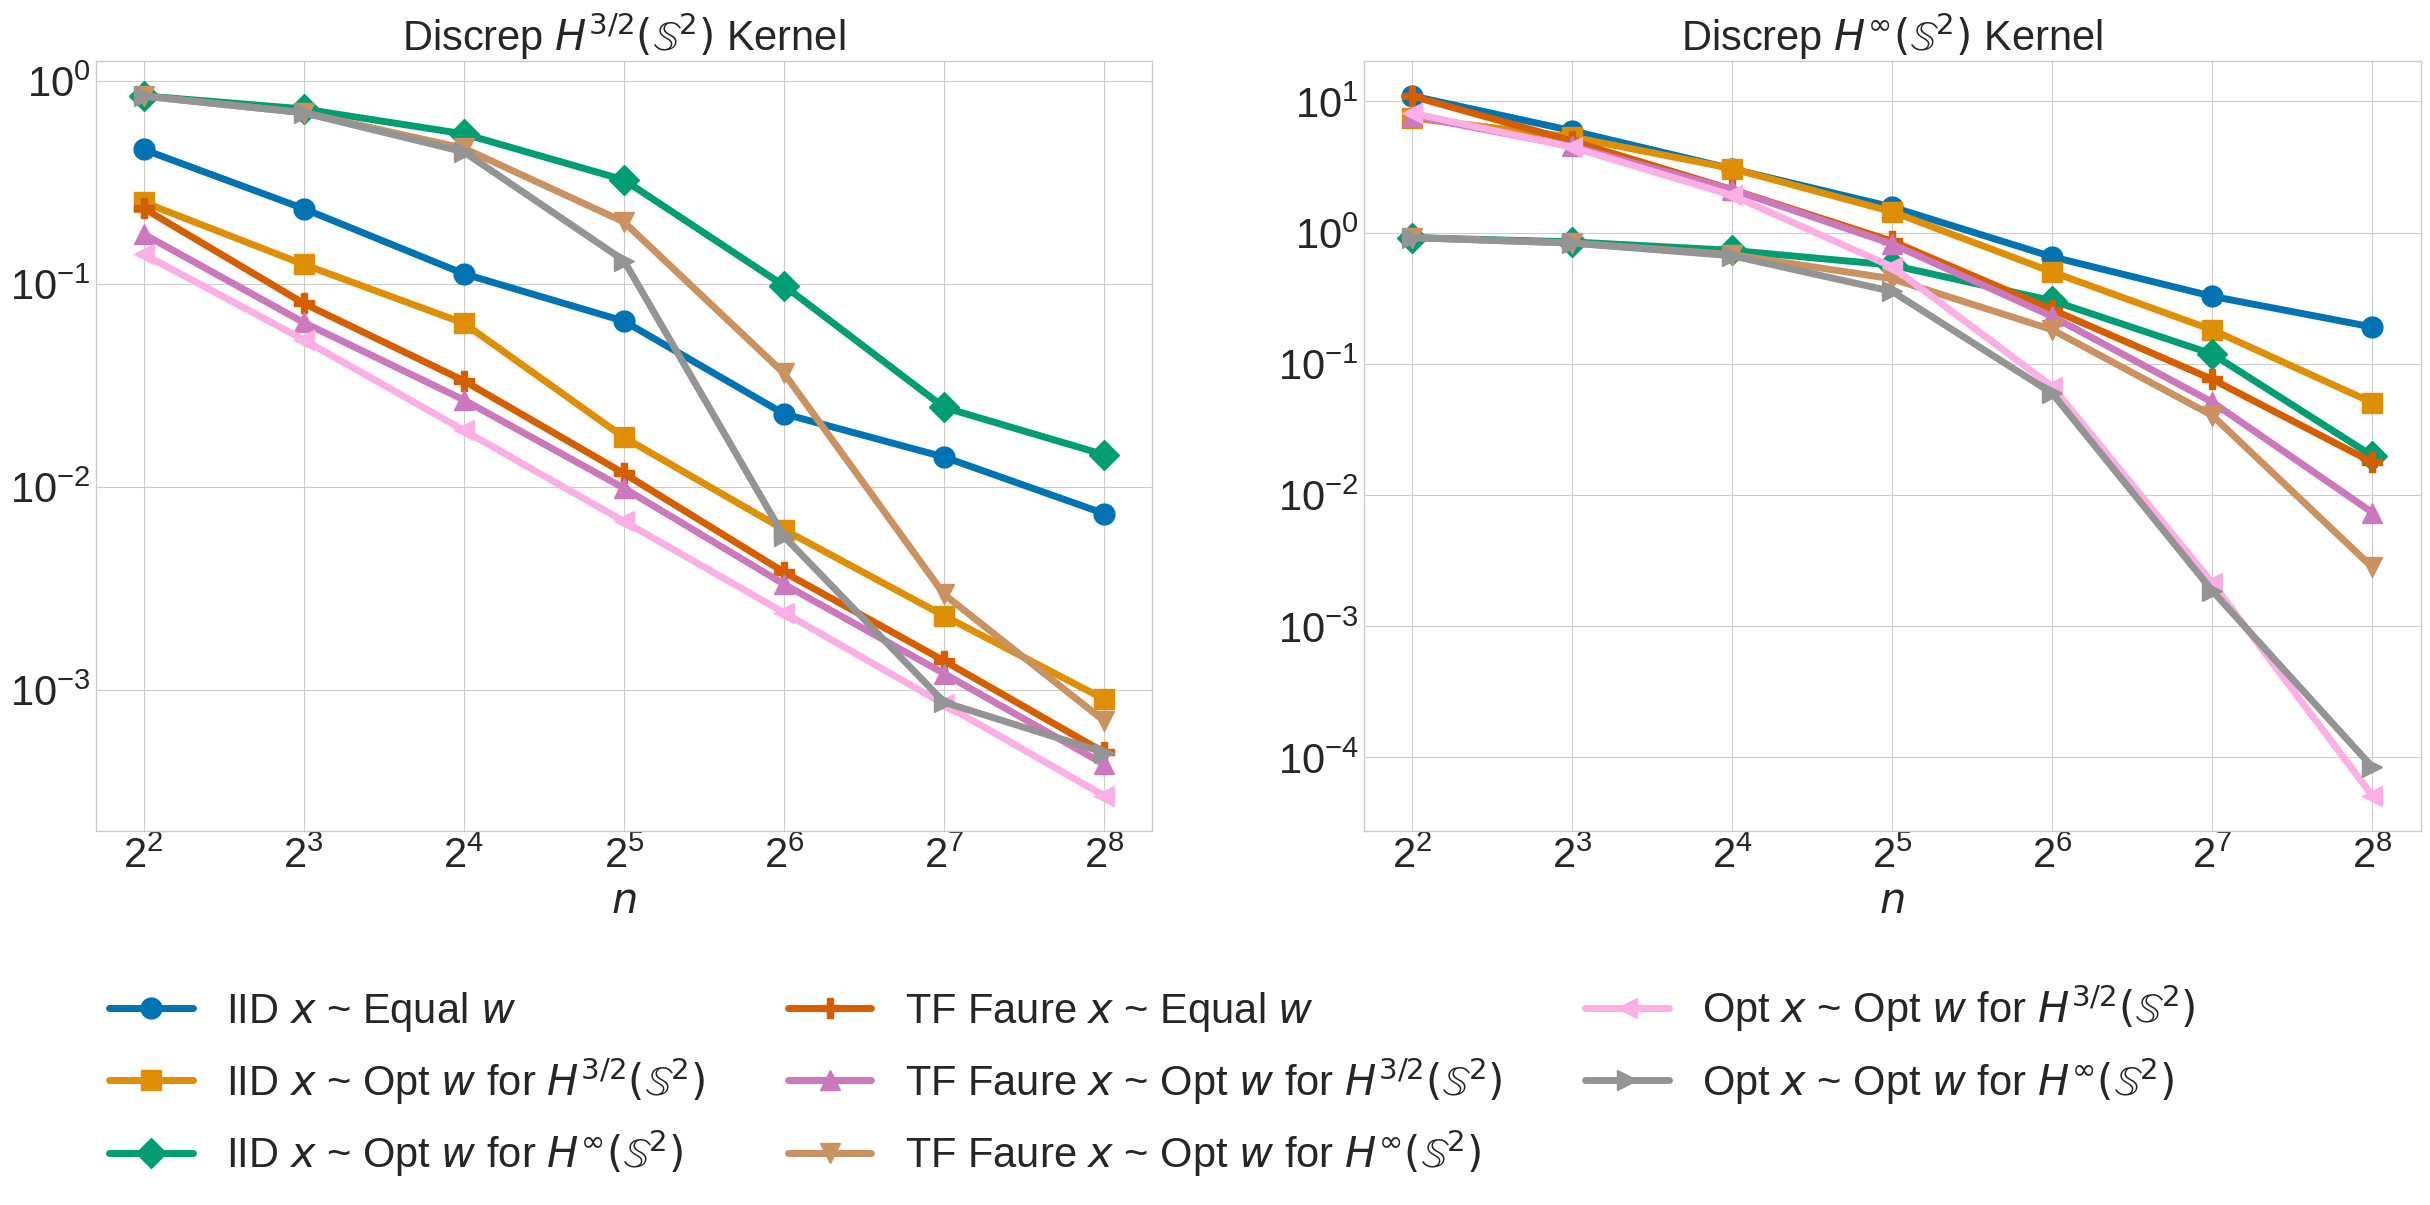

In [9]:
fig,ax = pyplot.subplots(nrows=1,ncols=2,figsize=(MPLP["PW"],MPLP["PW"]/3),sharex=True,sharey=False)
for i,(key,sphere_func) in enumerate(sphere_funcs):
    ax[0].plot(n,discreps_a[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
    ax[1].plot(n,discreps_b[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i])
ax[0].legend(frameon=False,ncols=3,loc="lower center",bbox_to_anchor=(1,-.5))
ax[0].set_title(r"Discrep $H^{3/2}(\mathbb{S}^2)$ Kernel")
ax[1].set_title(r"Discrep $H^\infty(\mathbb{S}^2)$ Kernel")
for i in range(2):
    ax[i].set_yscale("log",base=10)
    ax[i].set_xscale("log",base=2)
    ax[i].set_xlabel(r"$n$")

In [10]:
discreps_a_df = pd.DataFrame(discreps_a.median(-1).values.T,columns=[name for (name,func) in sphere_funcs])
discreps_a_df['n'] = n
discreps_a_df.set_index('n')
print(r"Discrep $H^{3/2}(\mathbb{S}^2)$ Kernel")
discreps_a_df


Discrep $H^{3/2}(\mathbb{S}^2)$ Kernel


,IID $x$ ~ Equal $w$,IID $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,IID $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,TF Faure $x$ ~ Equal $w$,TF Faure $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,TF Faure $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,Opt $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,Opt $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,n
0,0.459274,0.252485,0.844074,0.235786,0.175975,0.841915,0.140068,0.841409,4
1,0.234596,0.124533,0.727470,0.080099,0.064450,0.696690,0.053009,0.696073,8
2,0.112010,0.063952,0.548028,0.033278,0.026778,0.465685,0.018959,0.446819,16
3,0.065454,0.017503,0.325114,0.011625,0.009836,0.201773,0.006748,0.130183,32
4,0.022852,0.006142,0.097824,0.003790,0.003306,0.036203,0.002394,0.005683,64
5,0.013992,0.002308,0.024573,0.001385,0.001198,0.002943,0.000846,0.000865,128
6,0.007365,0.000896,0.014368,0.000490,0.000428,0.000700,0.000299,0.000489,256


In [11]:
discreps_b_df = pd.DataFrame(discreps_b.median(-1).values.T,columns=[name for (name,func) in sphere_funcs])
discreps_b_df['n'] = n
discreps_b_df.set_index('n')
print(r"Discrep $H^\infty(\mathbb{S}^2)$ Kernel")
discreps_b_df

Discrep $H^\infty(\mathbb{S}^2)$ Kernel


,IID $x$ ~ Equal $w$,IID $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,IID $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,TF Faure $x$ ~ Equal $w$,TF Faure $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,TF Faure $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,Opt $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$,Opt $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$,n
0,11.039714,7.471508,0.916941,11.000010,7.815019,0.916667,8.153932,0.916667,4
1,5.987468,5.364257,0.850602,5.005065,4.555003,0.833474,4.487088,0.833333,8
2,3.067579,3.080596,0.733064,2.131845,2.131178,0.680001,1.927198,0.666800,16
3,1.568610,1.444366,0.565487,0.861510,0.819246,0.445153,0.549719,0.356836,32
4,0.654481,0.501102,0.303158,0.259076,0.229941,0.182000,0.067190,0.059657,64
5,0.326993,0.181433,0.118800,0.076143,0.051045,0.040390,0.002136,0.001861,128
6,0.190908,0.050569,0.019874,0.017762,0.007346,0.002806,0.000051,0.000084,256
